# Machine Learning in Computational Biology Assignment #1
## *Epigenetic Age Prediction from DNA Methylation*
Data Science and Information Technologies - Spring 2026

Ioulios Konstantelos

## Introduction

Aging is accompanied by the disregulation of crucial cellular and organismal functions, which are tightly coupled with shifts in the genetic and epigenetic profile. These changes include DNA methylation, histone acetylations and hypoacetylation, transcriptional changes and modifications of RNA processing, which all participate in the formulation of senescence associated phenotype alterations.

Therefore, biological age is connected with the cellular epigenetic profile, and thus, understanding the main epigenetic factors for senescence can contribute to uncovering unknown mechanisms of aging-related diseases. On that point, it has been shown that DNA methylation patterns can be used to infer biological age with great accuracy. 

**This project aims at creating a robust Machine Learning Pipeline that predicts biological age and sex, from features derived from genome wide DNA Methylation patterns.**

## Notebook 1: Data Exploration

In the first notebook, the methylation dataset provided will be loaded and Exploratory Data Analysis will be performed. Furthermore, preprocessing and generation and selection of feature matrices with ablation experiments will be done. The input of this notebook is the development dataframe, while also the evaluation dataframe is loaded but remains locked, while the output are the finalized feature matrix and label vector, as well as plots from EDA.

## 1. Import required functions and Libraries

All custom functions used are loaded from the functions.py file, found on the src/ directory

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pickle
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from IPython.display import display


from src.functions import eda
from src.functions import stratified_split
from src.functions import feature_select
from src.functions import transform_beta_to_m
from src.functions import preprocessing
from src.functions import bootstrap_evaluation
from src.functions import plot_heteroscedasticity_beta_vs_mvalues
from src.functions import summarize_split
from src.functions import build_feature_matrices

## 2. Dataset loading and Exploratory Data Analysis (EDA)

### 2.1 Data Loading

On this step, both the developmment and the evaluation datasets are loaded. The development dataset will be used for training and evaluation of baseline models, while the evaluation dataframe will be treated as **locked** and will only be used for the final model evaluation.

In [2]:
#Load development and evaluation datasets to pandas DataFrames
dev_df = pd.read_csv("~/dsit/mlcb/data/development_data.csv")
evaluation_df = pd.read_csv("~/dsit/mlcb/data/evaluation_data.csv")
dev_df.head

X_development = dev_df.drop(columns=["sample_id", "age"])
y_development = dev_df["age"]


## 2.2 Exploratory Data Analysis (EDA)
Getting a first glance and visualizing the dataset that will be used is crucial to understand the features, and devise the way that the data will be handled and the model that will be used, to ensure the best possible predictions.

1. Development Dataset summmary table


Number of samples,456
Number of variables,1004
"Age, mean ± SD (years)",64.5 ± 14.6
Age range (years),19–101
"Male, n (%)",232 (50.9%)
"Female, n (%)",224 (49.1%)


2. Sex Class imbalance visualization


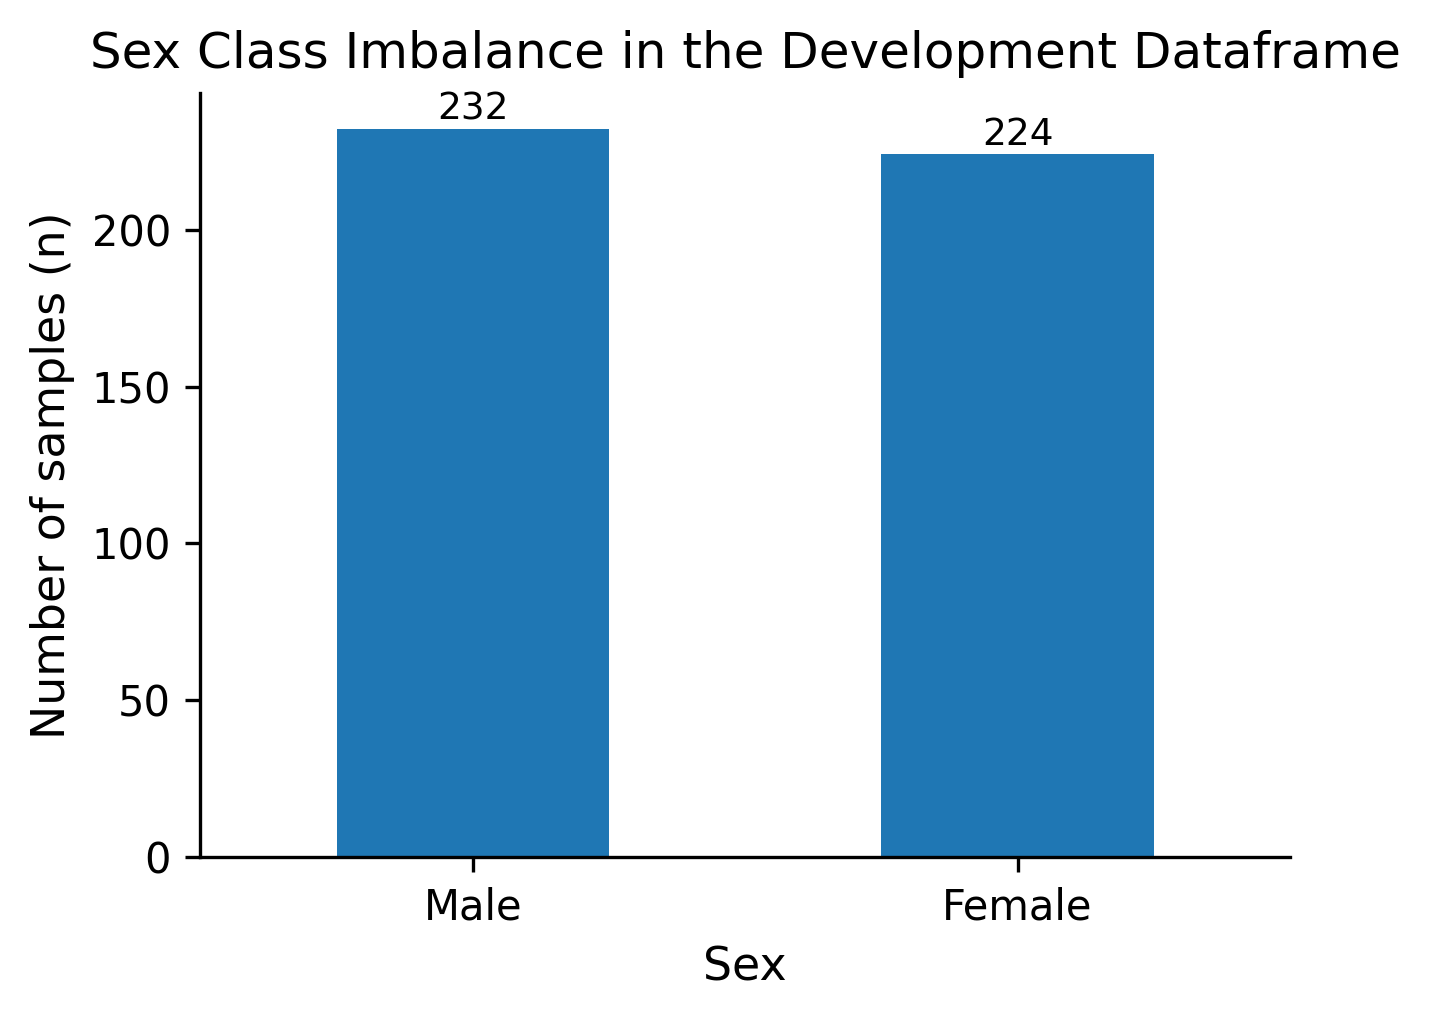

3. Distribution of Age in development dataframe


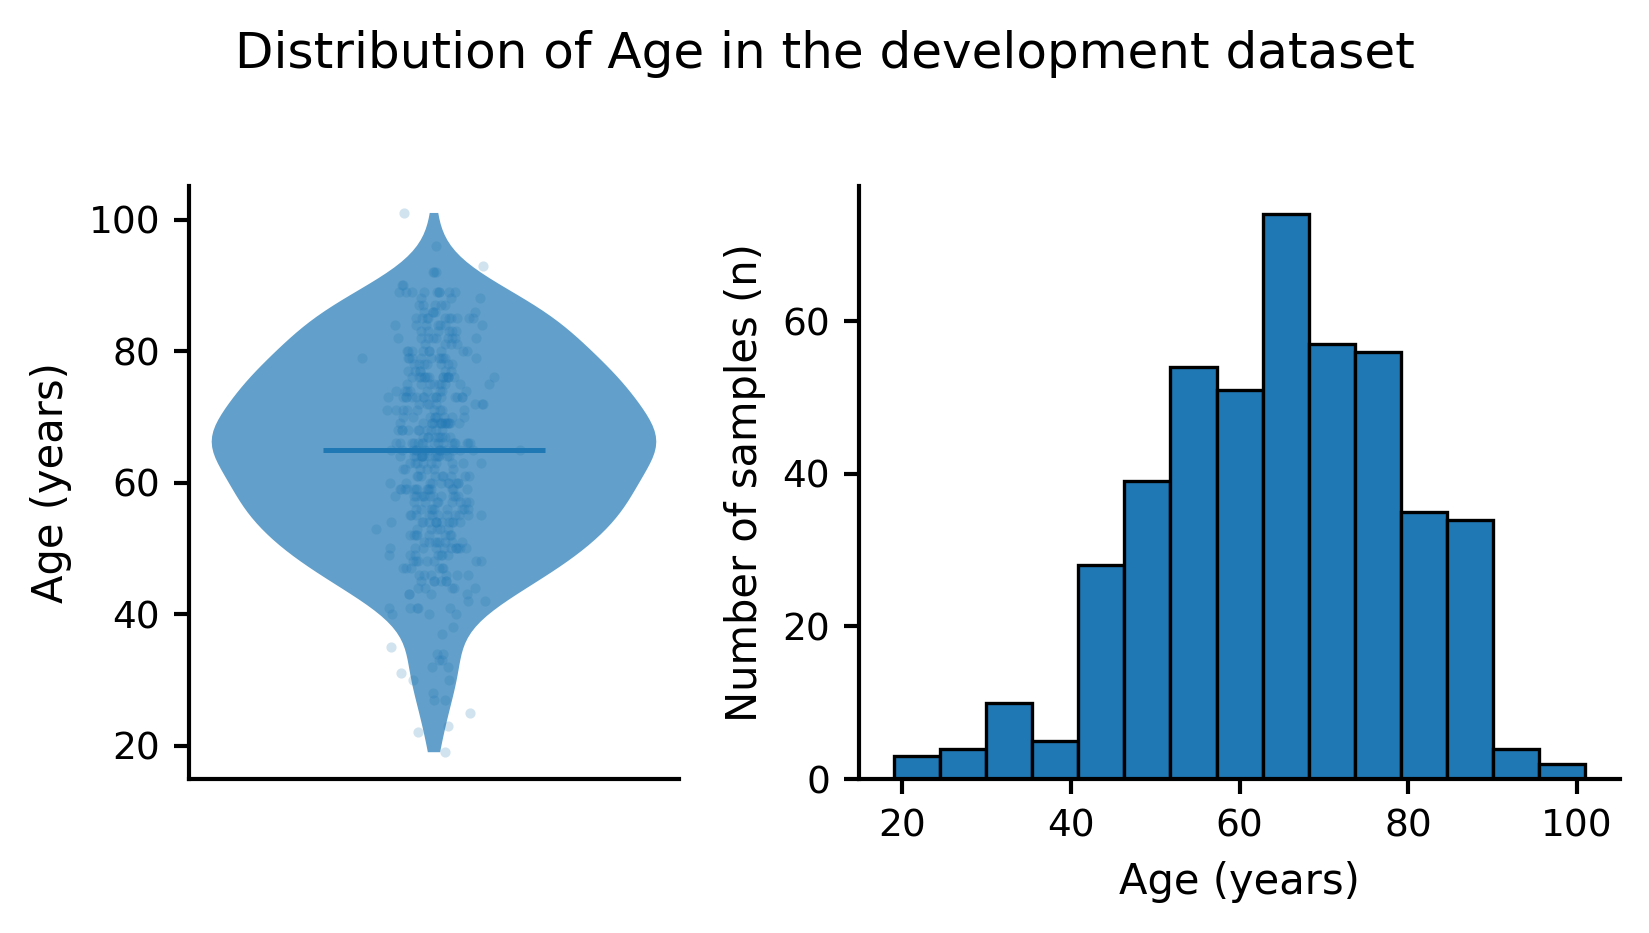

4.Feature Relationships Visualization


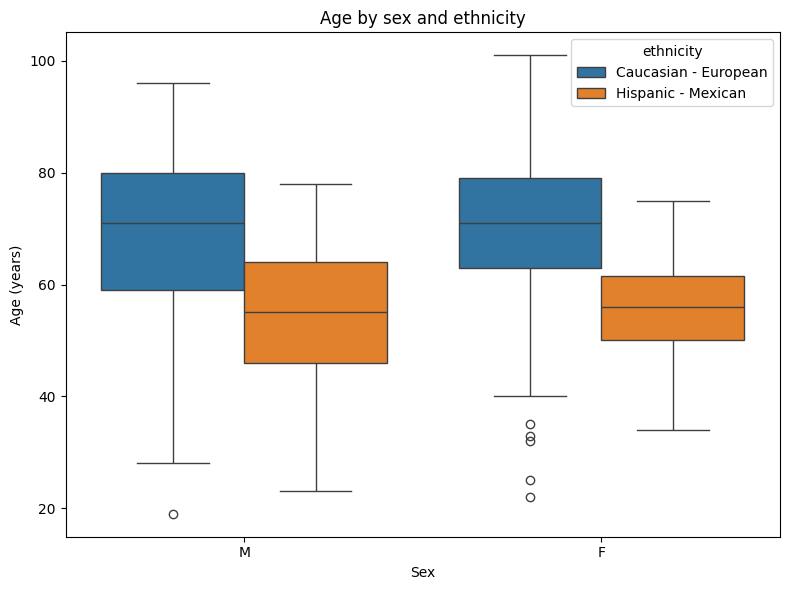

Correlation Matrix


Variable,Correlation with age
cg16867657,0.857
cg24724428,0.754
cg06639320,0.751
cg22454769,0.748
cg10501210,-0.743
cg21572722,0.735
cg24079702,0.702
cg07553761,0.684
cg19283806,-0.678
cg01974375,-0.677


Correlation Plot of Age and the most correlated features


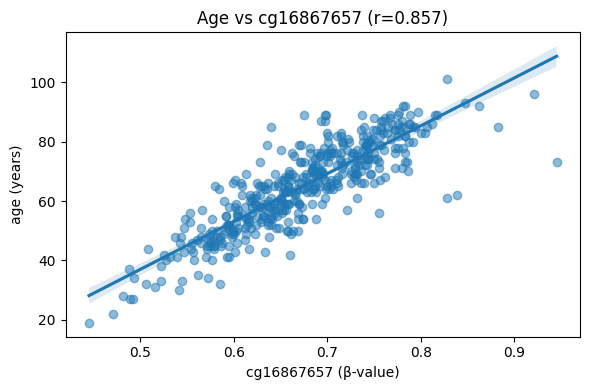

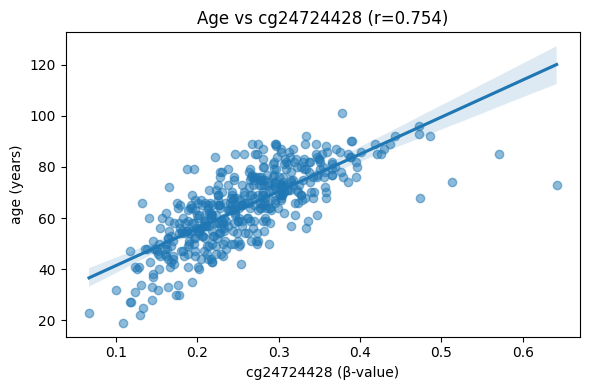

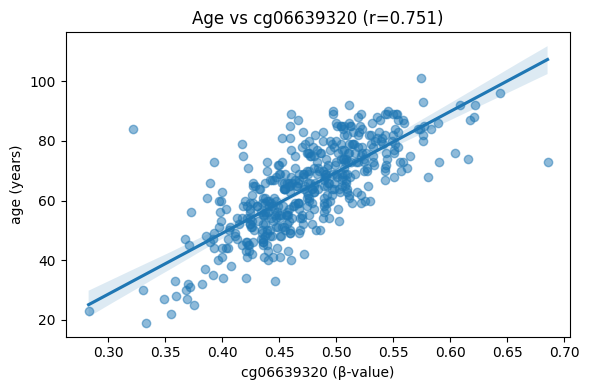

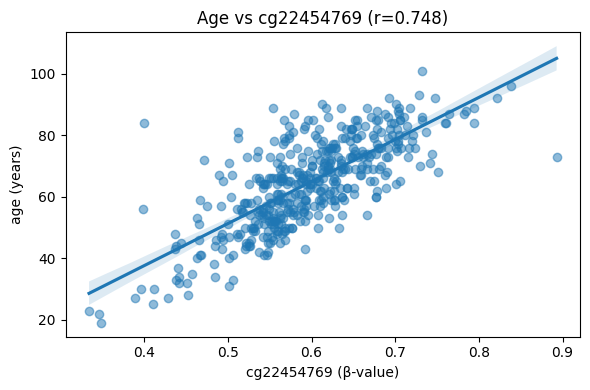

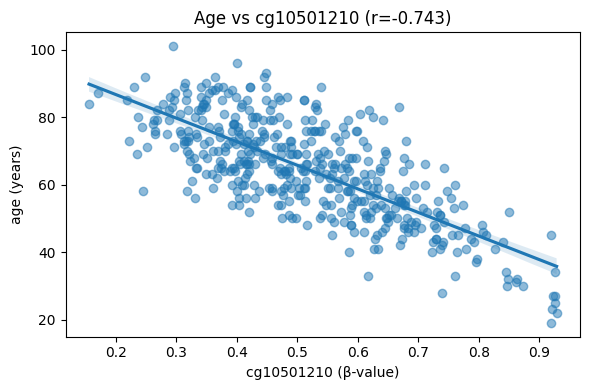

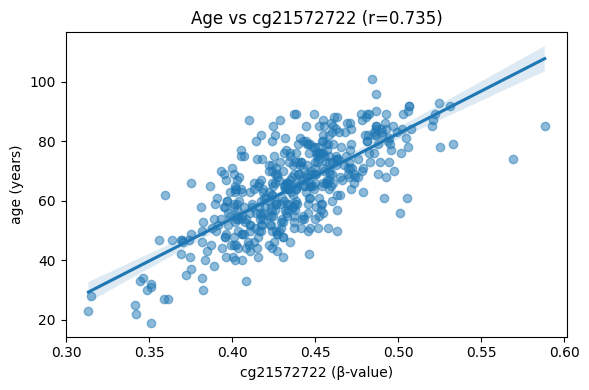

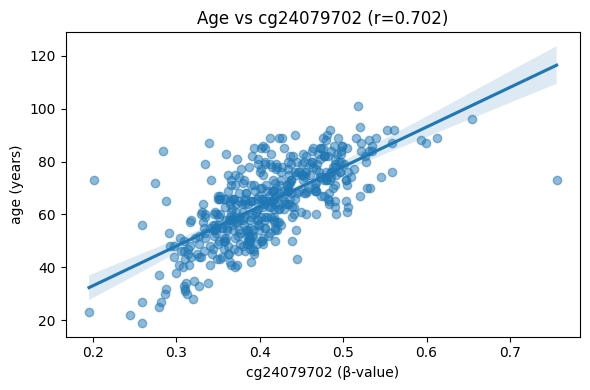

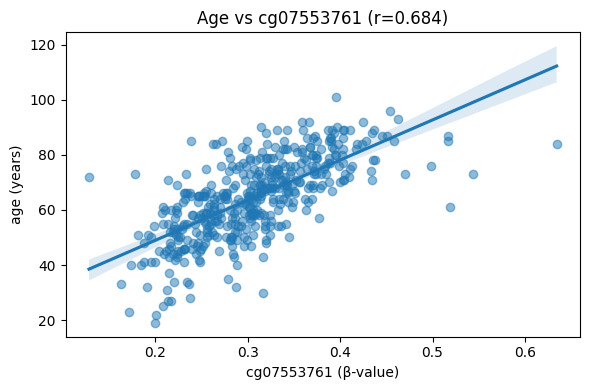

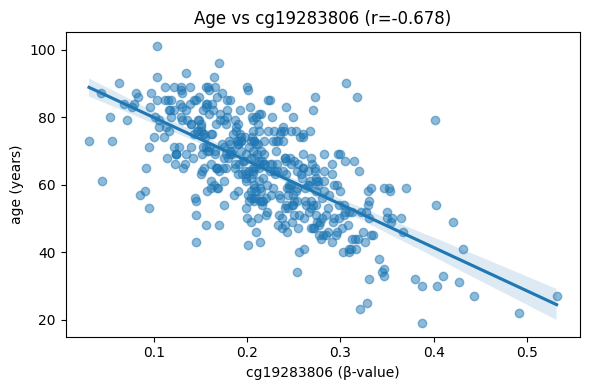

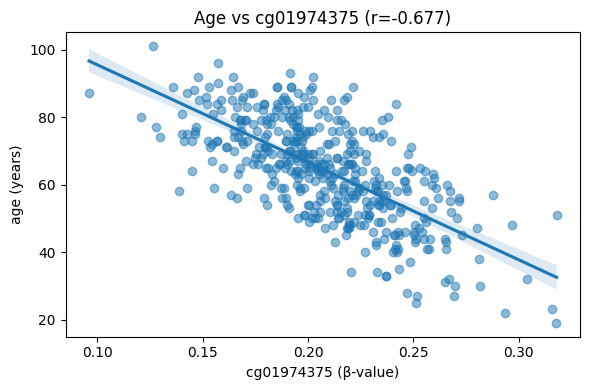

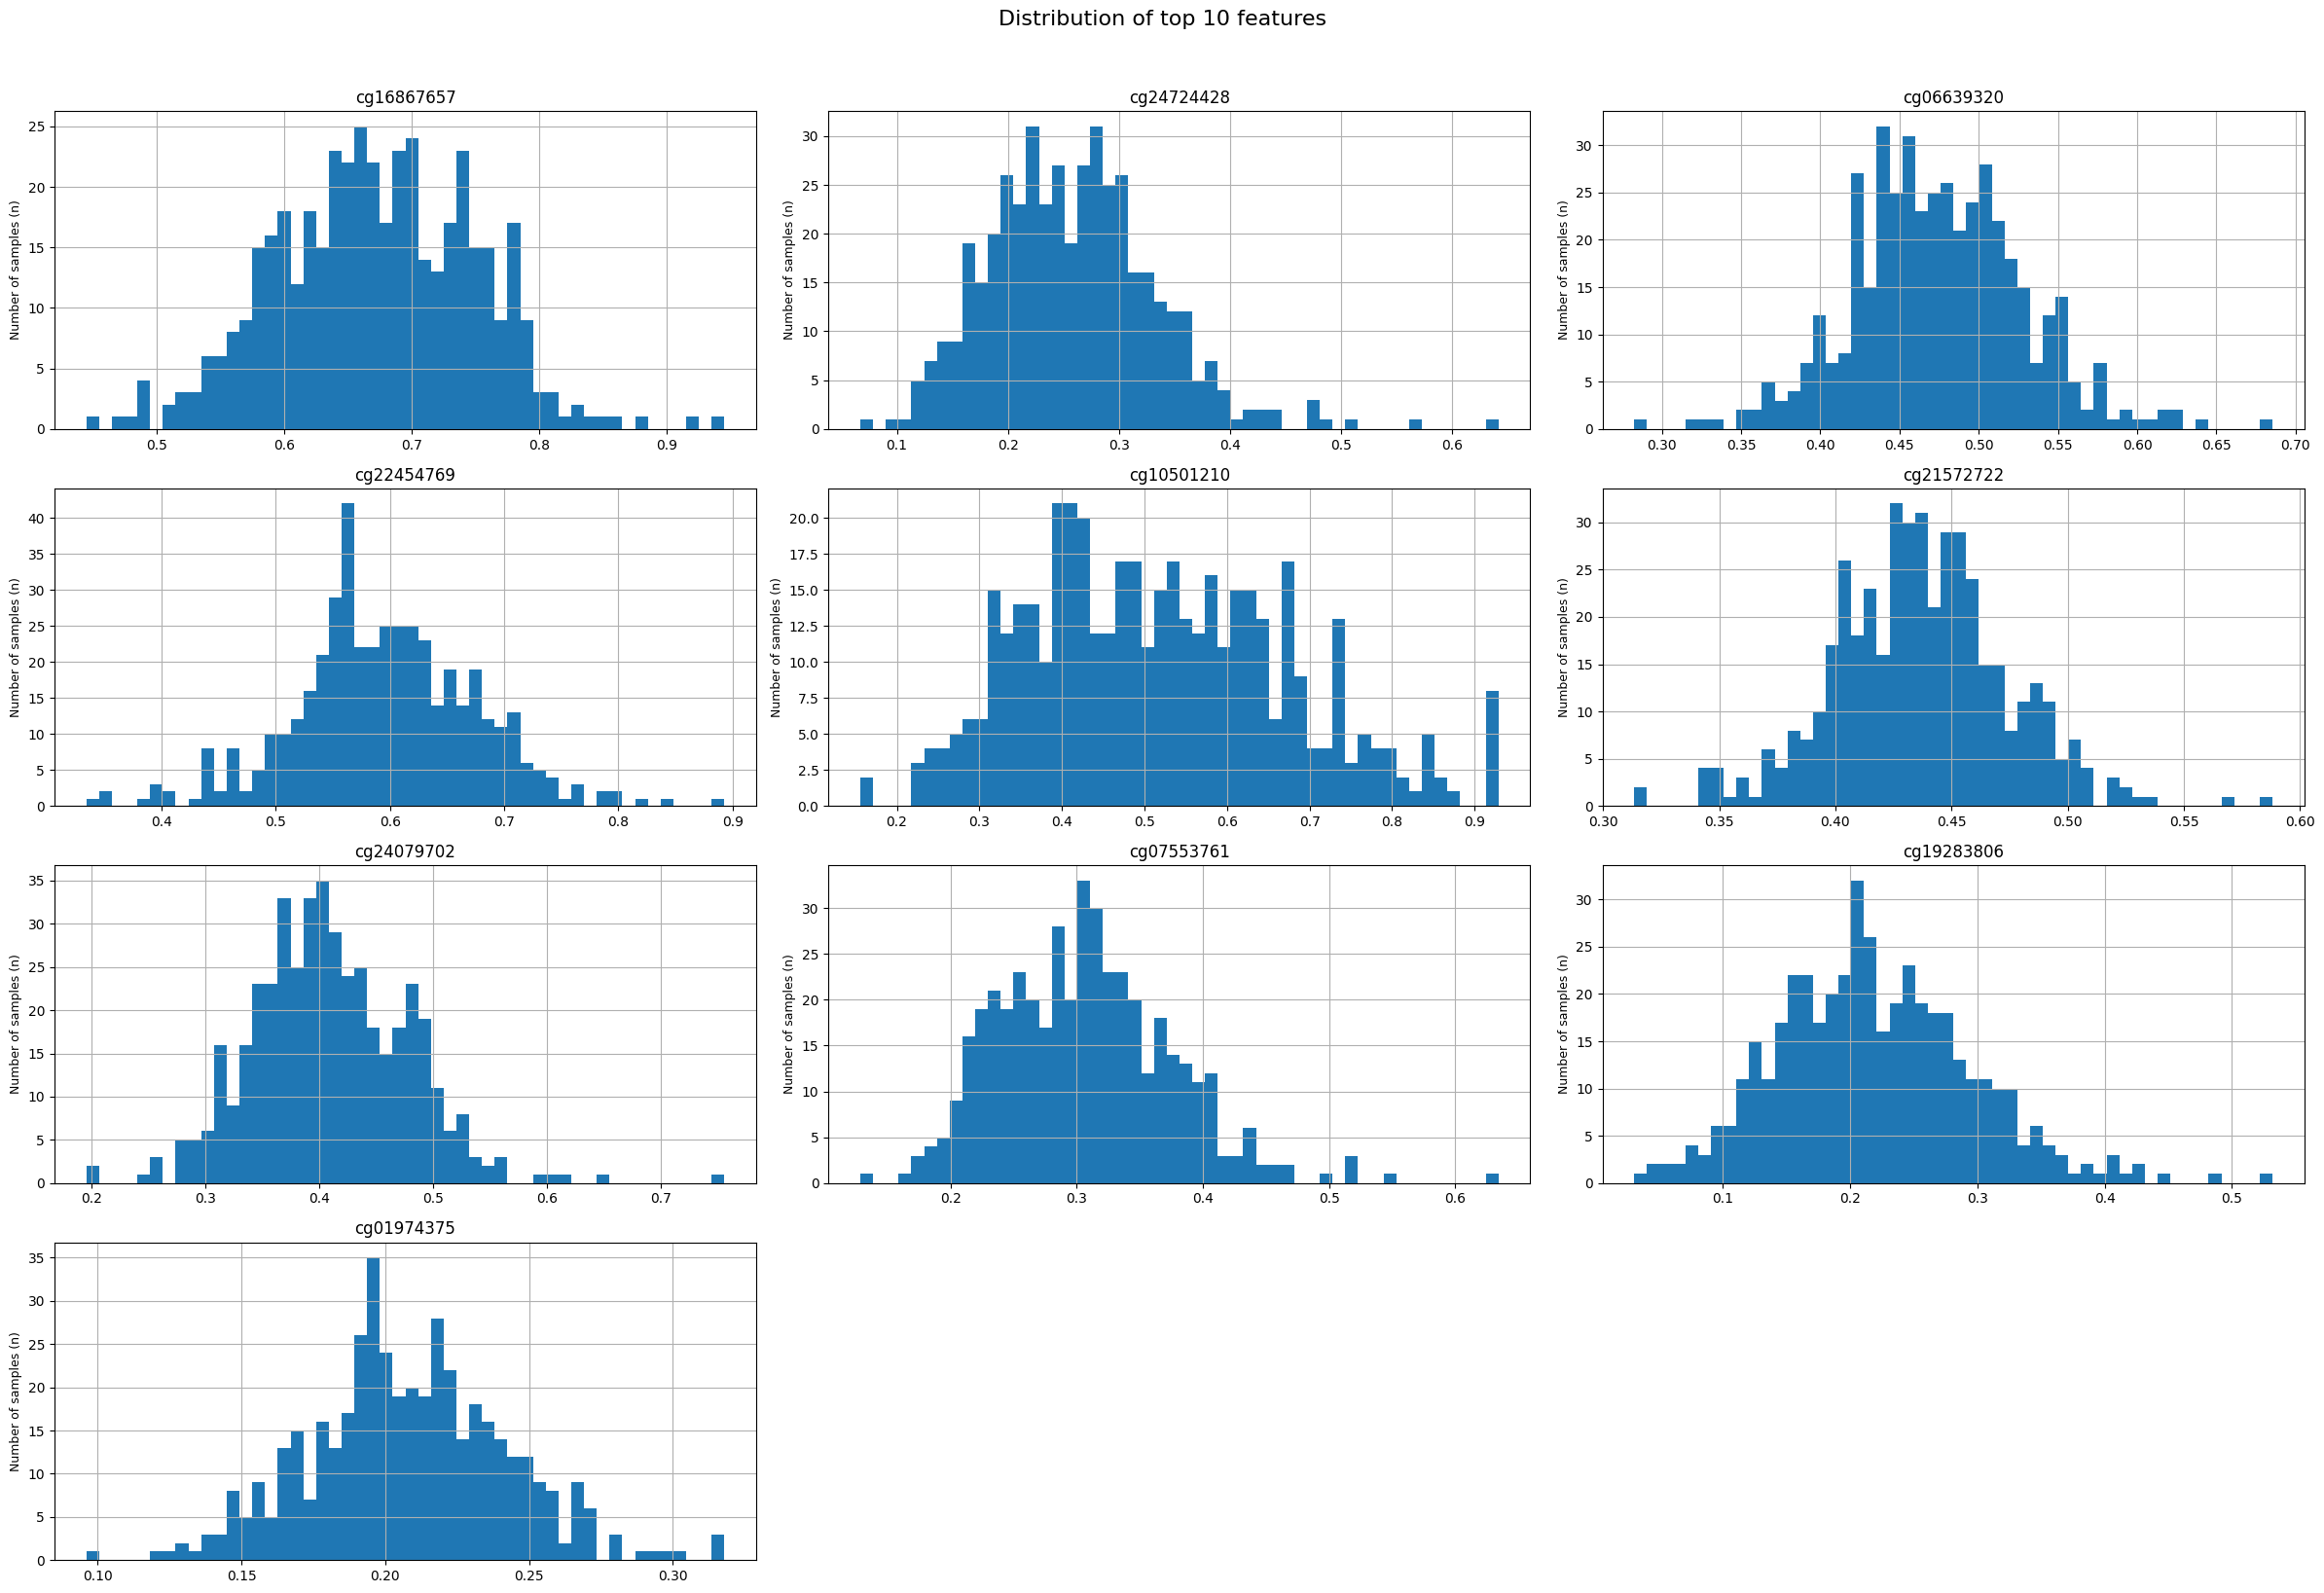

In [3]:
#Run Exploratory Data Analysis
metadata_cols = ["age","sex","ethnicity"]
eda(dev_df, "age", "age")

## 2.2.1 Comparison of heteroscedasticity in Beta and M-Values

Quantificationn of methylation levels by microarray analysis can be performed with either Beta- or M-methods. In all CpG islands analyses, methylation level is estimated on the measured intensities of a pair of microarray probes.

Beta-values are the most widely form of representation of methylation levels, ranging from 0 to 1, and is the method currently recommended by Illumina for methylation precentage measurment. M-values are the log-2 ratio of the intensities of the methylated probe versus unmethylated probe, and can be calculated as the logit of beta-values.

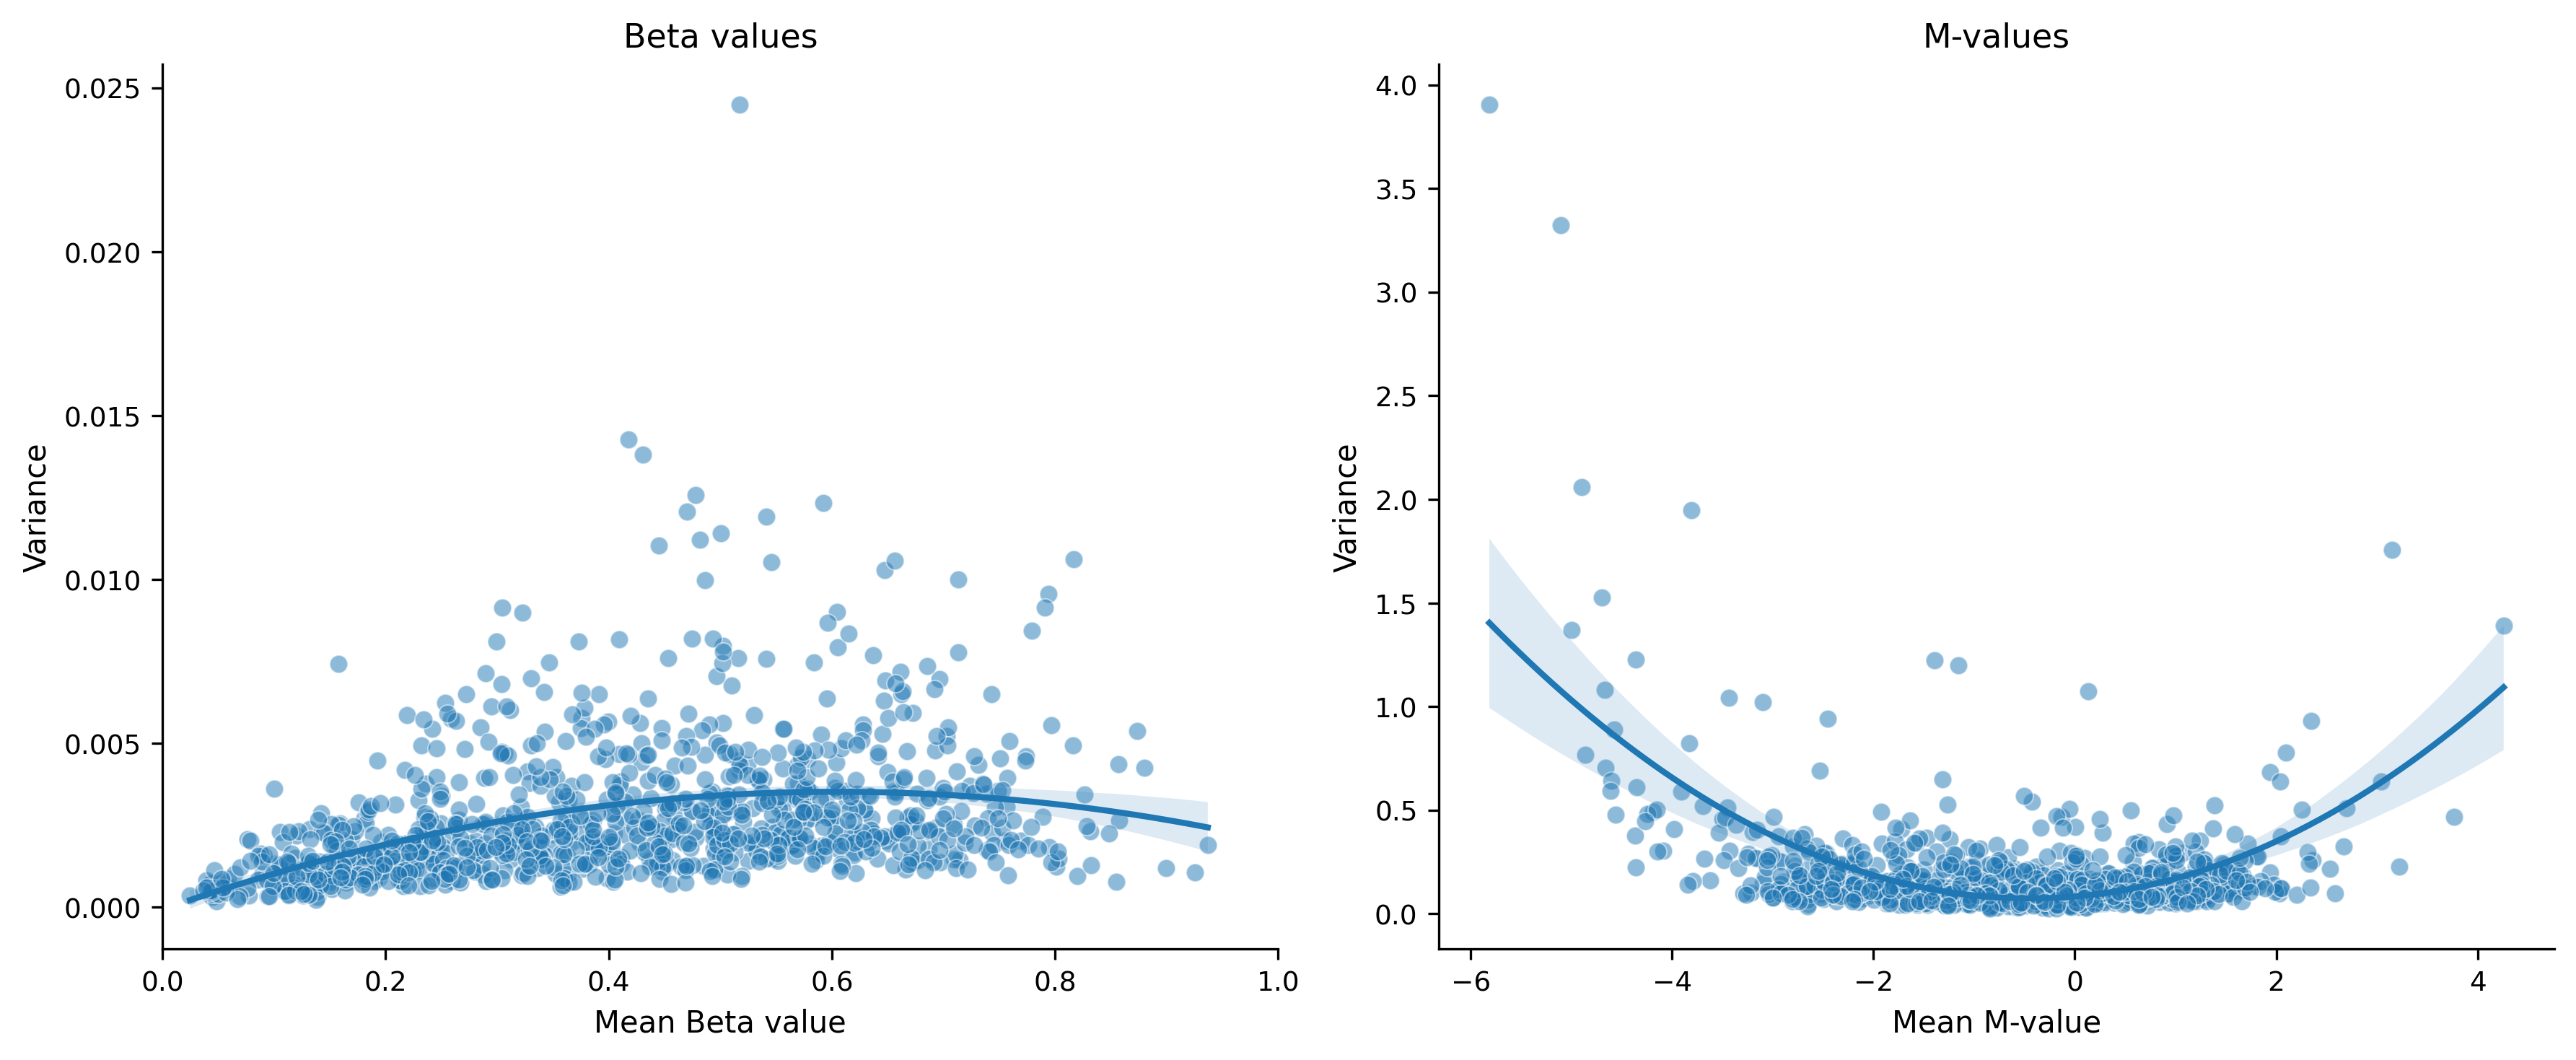

In [5]:
#Generate comparative b- M- plot
plot_heteroscedasticity_beta_vs_mvalues(
    development_df=dev_df,
    heteroscedasticity_prefix= "cg"
)

The plot indicates that Beta values are strongly affected by heteroscedasticity, with variance depending on the mean methylation level and becoming especially pronounced for highly methylated and unmethylated CpG sites. By comparison, M-values display a more stable variance structure, with the fitted trend remaining close to horizontal in the middle of the distribution, although higher variability is still observed at the lower and upper extremes.

 Reference: *Du, P., Zhang, X., Huang, CC. et al. Comparison of Beta-value and M-value methods for quantifying methylation levels by microarray analysis. BMC Bioinformatics 11, 587 (2010). https://doi.org/10.1186/1471-2105-11-587*

Thus, since this project is based on the use of **linear models** for age prediction, which are based on the assumption that the data have no heteroscedasticity, during preprocessing the beta values will be transformed to M-values. 

## 3. Data Splitting

To be able to train and validate the baseline models, the development dataset has to be split into an internal training / validation split. It is important that the splits are stratified by the target variable, which is age, to make sure that the examples are split evenly regarding age.

Age is a continous variable, which causes problems with stratification using scikit train-test split. To adress this problem, age can be handled as a discrete variable, by seperating the values into age group bins, of equal sizes. The design of this approach will be affected by the distribution of age in the development dataset, which will dictate the number of bins.

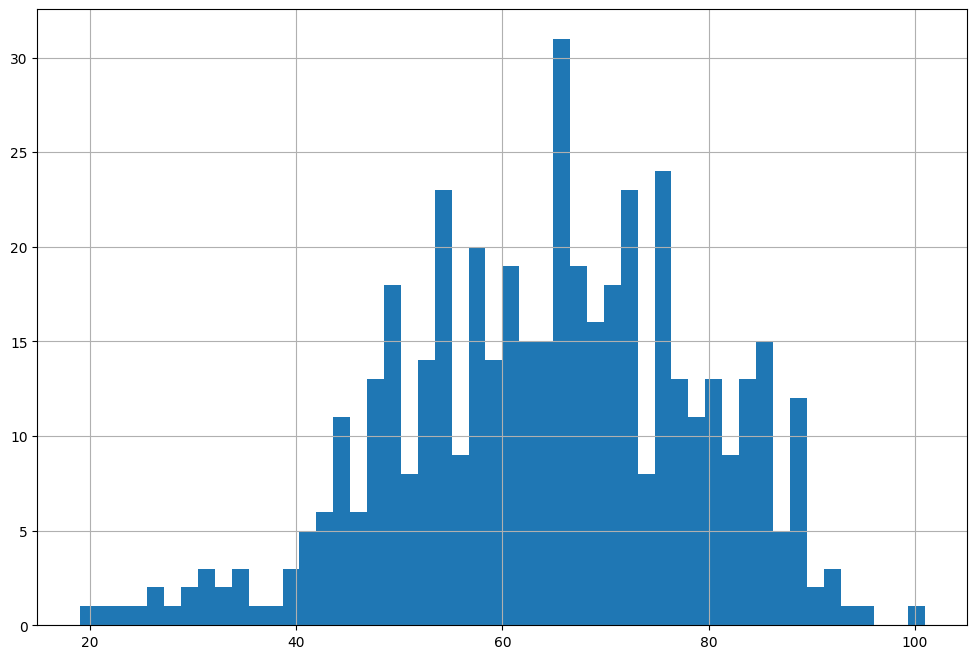

Mean: 64.45 +/- SD: 14.63


In [3]:
dev_df["age"].hist(bins=50, figsize=(12,8))
plt.show()
print(f"Mean: {dev_df['age'].mean():.2f} +/- SD: {dev_df['age'].std():.2f}")

In [3]:
# Set splitting parameters
seed = 42                       #Random seed for splitting (always 42)
training_size = 0.8             #Training set percentage (80%)
bin_num = 5                     #Number of bins for age stratification

#Split the methylation data
X_train, X_validate, y_train, y_validate = stratified_split(
    X_development, 
    y_development, 
    seed, 
    training_size, 
    bin_num
)

split_summary_table = pd.DataFrame([
    summarize_split(X_train, y_train, "Train"),
    summarize_split(X_validate, y_validate, "Test"),
    summarize_split(X_development, y_development, "Overall")
])

display(split_summary_table)


,Split,n,Age mean ± SD,Male n (%),Female n (%)
0,Train,364,64.5 ± 14.6,191 (52.5%),173 (47.5%)
1,Test,92,64.2 ± 14.7,41 (44.6%),51 (55.4%)
2,Overall,456,64.5 ± 14.6,232 (50.9%),224 (49.1%)


As expected from the EDA, age is not evenly distributed, with a mean of 64.45 and a Standard Deviation of 14.63, meaning most examples are around the age of 65, and less indicate very low or high age. To tackle this, a frequency binning approach will be followed. Data splitting is incorporated in the stratified_split function. The seed is always 42.

## 4. Data Preprocessing

### 4.1 Data Imputation

Many real biological datasets can contain missing values (NAs), due to either biological or technical factors. To adress missing values before model training, it is required to perform data imputation, which is  the correct replacement of these values after modelling the distribution of the training data. There is a wide variety of data imputation methods, and selecting the most proper one in each case is crucial, to retain and not alter the signal from the features, while also avoiding data shrinkage. The main factors that dictate feature selection method selection are:

- Missing data mechanism (MCAR, MAR etc.)
- Type of Data (Continuous numerical or Categorical)
- Proportion of Missing Values 

It is already known that the mechanism is MCAR (Missing Completely at Random). The proportion of Missing values will be now assesed:

In [ ]:
#Check precentage of missing values in the development set
na_precent = dev_df.isna().sum().sum() / dev_df.size * 100
print(f"Overall missing data: {na_precent:.2f}%")

Overall missing data: 3.00%


Given that the mechanism is MCAR, and the proportion of missing values on the development dataframe is low (3%), a simple imputation method will suffice. More specifically:

- For numerical data: Imputation by replacement with the median (More robust than the mean)
- For categorical data: Imputation by replacement with the most frequent value.

Source: *https://medium.com/@tarangds a-comprehensive-guide-to-data-imputation-techniques-strategies-and-best-practices-152a10fee543*

### 4.2 Preprocessing Numerical vs Categorical Features.

Numerical features were scaled using SciKit learn SimpleScaler. Feature scaling is an important preprocessing step because it places variables on a comparable scale, preventing features with larger numerical ranges from disproportionately influencing the model. This is especially important for linear models with regularization such as Elastic Net, where the penalty depends on the magnitude of the coefficients. By standardizing the input features, feature scaling improves numerical stability and fair weight prediction.

Categorical features were encoded via one-hot encoding. This is important because it converts categorical variables into a numerical format, which is interpretable by machine learning models.

The preprocessing process is incorporated into a preprocessor Pipeline, and is fit **exclusively** on the training set, and transforms both the training and the validation set, to avoid leakage.
The column transformer is incorporated in the preprocessing function from src.


## 5. Generation and selection of feature matrices, based on ablation experiments

Given that the given dataset contains both metadata (sex,ethnicity) and methylation data, feature matrices with combinations of methylation values and metadata will be constructed. 
 - Only Metadata : Age ,ethnicity and gender are correlated (Females live longer,different socioeconomic conditions across ethnicities)
 - Sex and methylation & Ethnicity and methylation : How does each metadata feature affect age prediction using methylation?
 - Only methylation : How well do methylation profiles alone predict age?
 - All features (methylation + metadata)

### 5.1 Generation of possible feature matrices

In [4]:
feature_matrices_train = build_feature_matrices(X_train)
feature_matrices_validate = build_feature_matrices(X_validate)

### 5.2 Ablation Experiments with a simple OLS model and different feature matrices

To make an educated decision on the feature matrix that will be used for the final ML pipeline, ablation experiments will be performed, where each feature matrix will be used on an Ordinary Least Squares (OLS) simple baseline model, and its performance will be assesed by bootstrapping and comparing:

- Root Mean Square Error (RMSE)
- Mean Absolute Error (MAE)
- Pearson r
- R squared

In [8]:
#Results dictionary
ols_results = {}

for matrix_name in feature_matrices_train.keys():
    X_train = feature_matrices_train[matrix_name]
    X_validate = feature_matrices_validate[matrix_name]

    preprocessor = preprocessing(X_train, "median", "most_frequent")

    ols_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    ols_pipeline.fit(X_train, y_train)
    y_pred = ols_pipeline.predict(X_validate)

    ols_boot_df = bootstrap_evaluation(
        confidence=0.95,
        prediction=y_pred,
        y_test=y_validate,
        resamples=1000,
        seed=seed
    )

    ols_results[matrix_name] = ols_boot_df
    print(matrix_name)
    display(ols_boot_df)
    print("\n")

1. Metadata Only


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,12.954505,1.248824,11.052966,15.994390
MAE,9.854019,0.889601,8.309387,11.843469
R_squared,0.213788,0.081912,0.043092,0.362325
Pearson_r,0.462923,0.084018,0.282804,0.604013




2. Methylation Only


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.253384,0.582993,4.414315,6.879332
MAE,3.909961,0.357236,3.299727,4.711132
R_squared,0.870707,0.033728,0.783662,0.919944
Pearson_r,0.935741,0.017363,0.889327,0.961236




3. Sex + Methylation


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.247181,0.584905,4.399329,6.881278
MAE,3.901968,0.357194,3.290094,4.713119
R_squared,0.871012,0.033783,0.783509,0.920240
Pearson_r,0.935887,0.017376,0.888899,0.961209




4. Ethnicity + Methylation


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.247780,0.582644,4.405432,6.877312
MAE,3.909766,0.356170,3.310363,4.708434
R_squared,0.870982,0.033636,0.783175,0.919905
Pearson_r,0.935959,0.017304,0.889381,0.961197




5. All Features


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.242055,0.584570,4.398977,6.885564
MAE,3.902270,0.356157,3.298502,4.725078
R_squared,0.871264,0.033696,0.784078,0.920452
Pearson_r,0.936089,0.017322,0.888888,0.961174


**Remarks:**
- Metadata alone carry substantially less predictive signal than methylation patterns (RMSE ~ 12.93, R squared ~ 0.21). This is expected, as variables such as sex and ethnicity may provide useful inductive bias and are broadly associated with biological and socioeconomic factors related to aging, but they are not sufficient on their own to accurately predict chronological age within a cohort.

- Incorporating either a single metadata factor or the full metadata set did not significantly improve model performance. This is consistent with the strong age-related signal already captured by the methylation subset of 1000 features, which likely dominates prediction, while the metadata contribute relatively limited additional predictive information.

In conclusion, to minimize features as much as possible, the metadata columns will be dropped, and all further analysis will be performed using only the methylation features (1000 features). If sex- and ethnicity- observations are required in further conclusions, these features can be reintroduced.

Now the features matrix X and labels vector y can be defined in a finalized form: They are saved to the data directory to be used on the models Notebook.

In [5]:
X_train_methylation = feature_matrices_train["2. Methylation Only"]
X_validate_methylation = feature_matrices_validate["2. Methylation Only"]
X_development_methylation = build_feature_matrices(X_development)["2. Methylation Only"]

with open("../data/X_train_methylation.pkl", "wb") as f:
    pickle.dump(X_train_methylation, f)

with open("../data/X_validate_methylation.pkl", "wb") as f:
    pickle.dump(X_validate_methylation, f)

with open("../data/y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open("../data/y_validate.pkl", "wb") as f:
    pickle.dump(y_validate, f)

with open("../data/X_development.pkl", "wb") as f:
    pickle.dump(X_development_methylation, f)

with open("../data/y_development.pkl", "wb") as f:
    pickle.dump(y_development, f)

###                                         ---------------------------------------------------------------------------------------------------------------- End of Notebook 1 ------------------------------------------------------------------------------------------------------